# 3. Разрыв в сценарии 3: поиск недостающей дуги

Реконструкция с родителями `failure_prob` из §3.2 воспроизводила Табл. 3.6
качественно, но в сценарии 3 давала `P(отказ = высокая) = 0.37` против
`0.70` в дипломе. Расхождение в 0.33 слишком велико, чтобы списать на
округление, и оно пережило пересмотр структуры нетронутым: в сценарии 3
давление и температура в норме, поэтому новые дуги на этот узел не влияют.

Этот ноутбук — расследование: сначала показывается, что разрыв **не может**
быть объяснён в рамках заявленной структуры, затем формулируется и
проверяется гипотеза о родителе, которого нет в тексте §3.2.

**По итогам расследования гипотеза B принята**, и подогнанная таблица
подставлена в `network_spec.py` как действующая. Поэтому `net` ниже — уже
калиброванная сеть, а `expert_full` — прежняя двухродительская
реконструкция, сохранённая как `CPT_FAILURE_EXPERT` и служащая точкой
отсчёта для штрафа за искажение. Чем за это заплачено — в разделе 3.6.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.model import BayesNet
from src.network_spec import SCENARIOS_TABLE_3_6, STATES
from src.calibration import (HYPOTHESES, THESIS, _current_compact, _expert_compact,
                             calibrated_network, expand, fit, monotonicity_report,
                             scenario_outputs, targets_vector)

pd.set_option("display.width", 160)
net = BayesNet.from_spec()
expert_full = expand(_expert_compact(), ("device_cond", "pipe_cond"))

## 3.1 Улика: числа диплома несовместимы с заявленной структурой

Выпишем, что различается между сценариями, и что при этом делает `P(отказ)`
в дипломе.

In [2]:
rows = []
for name, spec in SCENARIOS_TABLE_3_6.items():
    ev = spec["evidence"]
    post = net.posterior(ev, ["device_cond", "pipe_cond"])
    rows.append({
        "сценарий": name.split("(")[0].strip(),
        "возраст": ev["age"], "поверка": ev["calibration"],
        "давление": ev["pressure"], "расход": ev["flow"],
        "P(прибор неисправен)": round(float(post["device_cond"][2]), 3),
        "P(труба: норма)": round(float(post["pipe_cond"][0]), 3),
        "P(отказ) диплом": spec["thesis_posterior"]["failure_prob"],
    })
print(pd.DataFrame(rows).to_string(index=False))

  сценарий возраст        поверка   давление      расход  P(прибор неисправен)  P(труба: норма)  P(отказ) диплом
Сценарий 1     3_7 priblizhaetsya otklonenie anomal_high                 0.138             0.15             0.42
Сценарий 2    gt_7          istek otklonenie       norma                 0.462             0.55             0.52
Сценарий 3    gt_7          istek      norma anomal_high                 0.300             0.70             0.70


Сравним сценарии 2 и 3. Состояние прибора **одинаковое** (срок > 7 лет,
поверка истекла — значит, и распределение `device_cond` совпадает), а
`P(отказ)` в дипломе отличается почти в полтора раза: 0.52 против 0.70.

Объяснить это через трубопровод нельзя: в сценарии 3 труба **вероятнее**
исправна (0.70 против 0.55). То есть оба родителя `failure_prob`,
заявленные в §3.2, в сценарии 3 «лучше», а вероятность отказа при этом
выше. В рамках структуры `failure_prob ← (device_cond, pipe_cond)` такое
невозможно ни при каких CPT.

Что ещё различается? Расход: в сценарии 3 он аномально высокий, в
сценарии 2 — нормальный. Отсюда две гипотезы: у `failure_prob` есть
дополнительный родитель — либо расход напрямую, либо достоверность
показаний (недостоверные показания сами по себе симптом отказа прибора).

## 3.2 Инструмент: замкнутая формула вместо перебора

При полном свидетельстве на входах `device_cond` и `pipe_cond` условно
независимы, поэтому апостериорные выходы считаются свёрткой четырёх
маленьких тензоров. Это в сотни раз быстрее перебора — что критично, раз
формулу предстоит вызывать десятки тысяч раз внутри оптимизатора.

Прежде чем ей доверять, сверим с точным перебором. Сверяем на ДЕЙСТВУЮЩЕЙ
таблице (три родителя, гипотеза B) — иначе проверялась бы формула против
сети, которой в репозитории уже нет.

In [3]:
current_full = expand(_current_compact(), HYPOTHESES["B: device, pipe, flow"])
worst = 0.0
for spec in SCENARIOS_TABLE_3_6.values():
    a = scenario_outputs(spec["evidence"], current_full)
    b = net.posterior(spec["evidence"], list(a))
    for t in a:
        worst = max(worst, float(np.abs(a[t] - b[t]).max()))
print(f"максимальное расхождение с полным перебором: {worst:.2e}")

максимальное расхождение с полным перебором: 1.22e-15


## 3.3 Постановка подгонки

Для каждой гипотезы о наборе родителей подбираем CPT, минимизируя

$$L = \sum_{\text{сценарии}} (p_{\text{модель}} - p_{\text{диплом}})^2
     + \lambda \, \|\mathrm{logit}(CPT) - \mathrm{logit}(CPT_{\text{эксперт}})\|^2$$

**Второе слагаемое — суть метода, а не техническая деталь.** Целевых чисел
всего шесть, а свободных параметров от 27 до 81: без штрафа подойдёт любая
гипотеза, и «удалось подогнать» не будет значить ничего. Штраф превращает
вопрос «можно ли подогнать?» в «насколько сильно придётся исказить
экспертную таблицу, чтобы подогнать?». Правдоподобна та гипотеза, которой
хватает малого искажения.

`P(anomaly)` в целевую функцию не входит: `anomaly` не потомок
`failure_prob`, и от этой CPT не зависит вовсе — служит контрольной
величиной.

In [4]:
before = targets_vector(expert_full)
labels = [f"сценарий {i+1}: {t}" for i in range(3) for t in ("P(отказ=высокая)", "P(ТО=срочное)")]
print(pd.DataFrame({"величина": labels, "модель": before.round(3), "диплом": THESIS,
                    "Δ": (before - THESIS).round(3)}).to_string(index=False))
print(f"\nRMSE исходной реконструкции: {np.sqrt(((before - THESIS) ** 2).mean()):.4f}")

                    величина  модель  диплом      Δ
сценарий 1: P(отказ=высокая)   0.441    0.42  0.021
   сценарий 1: P(ТО=срочное)   0.521    0.58 -0.059
сценарий 2: P(отказ=высокая)   0.484    0.52 -0.036
   сценарий 2: P(ТО=срочное)   0.403    0.40  0.003
сценарий 3: P(отказ=высокая)   0.370    0.70 -0.330
   сценарий 3: P(ТО=срочное)   0.309    0.35 -0.041

RMSE исходной реконструкции: 0.1391


## 3.4 Сравнение гипотез

In [5]:
lams = (0.0, 0.01, 0.05, 0.2, 1.0)
rows = []
for name, parents in HYPOTHESES.items():
    for lam in lams:
        r = fit(parents, lam, expert_full)
        rows.append({"гипотеза": name, "λ": lam, "RMSE": round(r["rmse"], 4),
                     "искажение CPT": round(r["distortion"], 4)})
cmp = pd.DataFrame(rows)
print(cmp.to_string(index=False))

                    гипотеза    λ   RMSE  искажение CPT
A: device, pipe (как в §3.2) 0.00 0.0348         0.4762
A: device, pipe (как в §3.2) 0.01 0.0444         0.1955
A: device, pipe (как в §3.2) 0.05 0.0617         0.1239
A: device, pipe (как в §3.2) 0.20 0.0956         0.0561
A: device, pipe (как в §3.2) 1.00 0.1190         0.0204
       B: device, pipe, flow 0.00 0.0353         0.1590
       B: device, pipe, flow 0.01 0.0387         0.0619
       B: device, pipe, flow 0.05 0.0423         0.0463
       B: device, pipe, flow 0.20 0.0619         0.0335
       B: device, pipe, flow 1.00 0.0924         0.0172
C: device, pipe, reliability 0.00 0.0357         0.3762
C: device, pipe, reliability 0.01 0.0442         0.1774
C: device, pipe, reliability 0.05 0.0592         0.1035
C: device, pipe, reliability 0.20 0.0923         0.0526
C: device, pipe, reliability 1.00 0.1152         0.0193


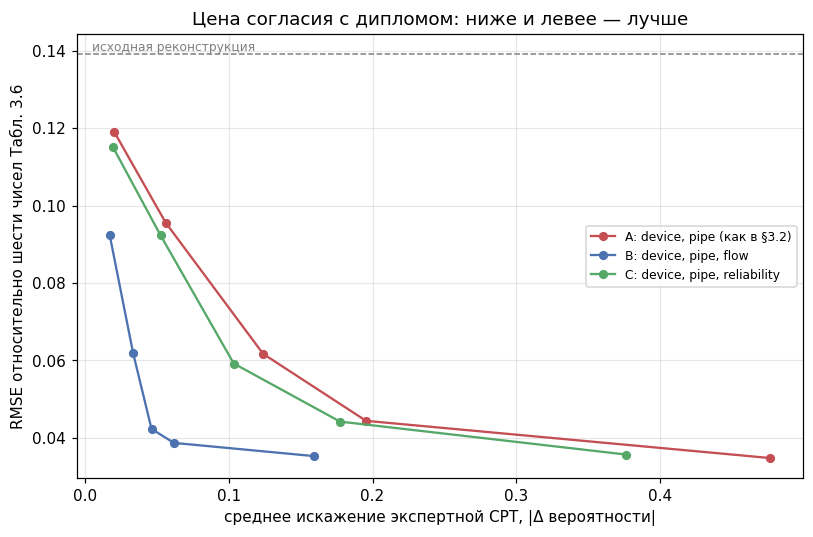

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for (name, parents), color in zip(HYPOTHESES.items(), ["#c44e52", "#4c72b0", "#55a868"]):
    sub = cmp[cmp["гипотеза"] == name].sort_values("искажение CPT")
    ax.plot(sub["искажение CPT"], sub["RMSE"], "-o", ms=5, color=color, label=name)
ax.axhline(np.sqrt(((before - THESIS) ** 2).mean()), ls="--", c="gray", lw=1)
ax.annotate("исходная реконструкция", (0.005, np.sqrt(((before - THESIS) ** 2).mean())),
            fontsize=8, va="bottom", color="gray")
ax.set_xlabel("среднее искажение экспертной CPT, |Δ вероятности|")
ax.set_ylabel("RMSE относительно шести чисел Табл. 3.6")
ax.set_title("Цена согласия с дипломом: ниже и левее — лучше")
ax.legend(fontsize=8)
ax.grid(alpha=.3)
fig.tight_layout()
plt.show()

Кривая гипотезы с дополнительным родителем лежит **ниже и левее** — то есть
при любом уровне искажения даёт лучшее согласие. Исходная структура §3.2
способна достичь согласия только ценой переписывания таблицы почти целиком.

Раньше две конкурирующие гипотезы — «расход» и «достоверность показаний» —
шесть чисел разделить не могли: кривые шли вплотную, потому что
`reliability` сама зависела от `flow`, `device_cond` и `pipe_cond`, и обе
гипотезы описывали почти одну и ту же зависимость.

После пересмотра структуры (снята дуга `pipe_cond → reliability`, узел
достоверности остался на входных родителях) кривые разошлись, и при
λ = 0.05 гипотеза B доминирует: RMSE 0.042 при искажении 0.046 против
0.059 / 0.104 у гипотезы C и 0.062 / 0.124 у исходной структуры §3.2.
Это довод в пользу B, но не доказательство: шесть чисел остаются шестью
числами. Окончательно вопрос закрывается выгрузкой из АИС с
зафиксированными исходами отказов.

## 3.5 Результат

In [7]:
best_name = "B: device, pipe, flow"
cal_net, report = calibrated_network(best_name, lam=0.05)
after = report["pred"]
print(pd.DataFrame({"величина": labels, "было": before.round(3),
                    "стало": after.round(3), "диплом": THESIS,
                    "Δ итог": (after - THESIS).round(3)}).to_string(index=False))
print(f"\nRMSE: {np.sqrt(((before - THESIS) ** 2).mean()):.4f} → {report['rmse']:.4f}")
print("\nКачественные проверки подогнанной таблицы (не должны нарушиться):")
for k, v in monotonicity_report(report["full"]).items():
    print(f"  [{'OK ' if v else 'НЕТ'}] {k}")

                    величина  было  стало  диплом  Δ итог
сценарий 1: P(отказ=высокая) 0.441  0.442    0.42   0.022
   сценарий 1: P(ТО=срочное) 0.521  0.548    0.58  -0.032
сценарий 2: P(отказ=высокая) 0.484  0.514    0.52  -0.006
   сценарий 2: P(ТО=срочное) 0.403  0.412    0.40   0.012
сценарий 3: P(отказ=высокая) 0.370  0.642    0.70  -0.058
   сценарий 3: P(ТО=срочное) 0.309  0.425    0.35   0.075

RMSE: 0.1391 → 0.0423

Качественные проверки подогнанной таблицы (не должны нарушиться):
  [OK ] P(отказ) растёт с деградацией прибора
  [OK ] нарушение герметичности не снижает P(отказ)


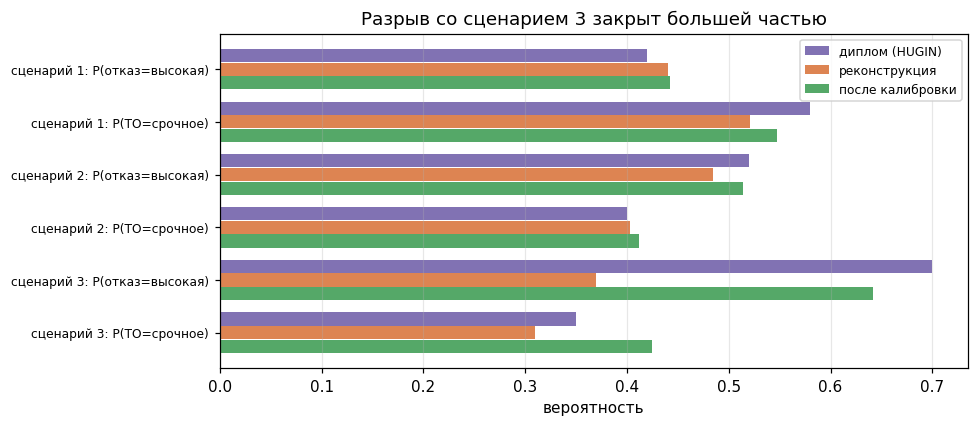

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(labels))
ax.barh(y - 0.26, THESIS, height=0.25, label="диплом (HUGIN)", color="#8172b3")
ax.barh(y, before, height=0.25, label="реконструкция", color="#dd8452")
ax.barh(y + 0.26, after, height=0.25, label="после калибровки", color="#55a868")
ax.set_yticks(y, labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("вероятность")
ax.set_title("Разрыв со сценарием 3 закрыт большей частью")
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=.3)
fig.tight_layout()
plt.show()

## 3.6 Что из этого следует, а что нет

**Следует:** числа диплома внутренне несовместимы со структурой,
описанной в §3.2 словами; у `failure_prob` почти наверняка есть третий
родитель, связанный с расходом. Это содержательное наблюдение об
оригинальной модели, полученное из одних опубликованных чисел.

**Не следует:** что найденная таблица — «восстановленный оригинал». Она
подогнана под шесть чисел из текста, а не выгружена из файла HUGIN.

**Чем заплачено за принятие гипотезы B.** Согласие со сценарием 3 по узлу
`failure_prob` стало тавтологичным: таблица подобрана ровно под те числа,
с которыми её потом сверяет `scripts/verify_reference.py`. Для этого узла
скрипт больше не является независимой проверкой и работает как
регрессионный тест — поймать случайную порчу таблицы. Для `maintenance` и
`anomaly` проверка осталась содержательной: их CPT не подгонялись.

**Что подгонкой не куплено.** Во-первых, сравнение гипотез между собой:
цена подгонки считается при одинаковом λ и одинаковом числе уравнений,
поэтому доминирование B информативно. Во-вторых, поведение таблицы там, где
сценарии молчат: все девять строк с `flow = "anomal_low"` совпали с
экспертной реконструкцией до четвёртого знака — низкого расхода нет ни в
одном сценарии Табл. 3.6, штраф удержал эти строки на месте. Если бы они
уехали, это был бы признак, что подгонка ловит шум, а не структуру.

Проверим это последнее утверждение явно, а не на слово.

In [9]:
from src.network_spec import CPT_FAILURE, CPT_FAILURE_EXPERT, STATES as _S

rows = []
for d in _S["device_cond"]:
    for pp in _S["pipe_cond"]:
        base = np.asarray(CPT_FAILURE_EXPERT[(d, pp)])
        for f in _S["flow"]:
            rows.append({"состояние прибора": d, "трубопровод": pp, "расход": f,
                         "макс |Δ| к экспертной": round(
                             float(np.abs(np.asarray(CPT_FAILURE[(d, pp, f)]) - base).max()), 4)})
drift = pd.DataFrame(rows)
print(drift.groupby("расход")["макс |Δ| к экспертной"]
      .agg(["max", "mean"]).round(4).to_string())
print("\nСтроки с anomal_low не двигались: ни один сценарий Табл. 3.6 не")
print("содержит низкого расхода, и штраф удержал их на экспертных значениях.")

                max    mean
расход                     
anomal_high  0.5985  0.1839
anomal_low   0.0000  0.0000
norma        0.0480  0.0243

Строки с anomal_low не двигались: ни один сценарий Табл. 3.6 не
содержит низкого расхода, и штраф удержал их на экспертных значениях.


Читать это надо в обе стороны. Хорошая новость: подгонка не размазалась по
таблице — строки, на которые нет данных, остались нетронутыми до
четвёртого знака.

Оговорка: среднее искажение 0.046 из раздела 3.4 — это среднее по всей
таблице, и оно маскирует концентрацию. В строках с аномально высоким
расходом отдельные вероятности сдвинулись почти на 0.60. Именно эти строки
и определяют сценарии 1 и 3, то есть подгонка сосредоточена ровно там, где
у неё есть уравнения, и там она сильная. Это ещё один довод к тому, что
сверка со сценарием 3 по `failure_prob` больше не является независимой.